# BloodBridge AI — Exploratory Data Analysis

In this notebook, we perform an Exploratory Data Analysis (EDA) on the simulated daily blood bank operational dataset. We analyze inventory levels, donation/request patterns, and check the data for sanity and missing values.

In [1]:
from pathlib import Path
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Locate project root
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
    
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "reports"
DATA_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

print(f"Project root identified: {ROOT}")

Project root identified: C:\Users\dhair\OneDrive\Desktop\College\Project\project implementation part\BloodBridge_AI


### Load the Simulation Dataset

First, we make sure the synthetic dataset is generated by executing the generation script if the file does not already exist. Then, we load the CSV and review the schema.

In [2]:
dataset_path = DATA_DIR / "interim" / "synthetic_daily_blood_inventory.csv"

if not dataset_path.exists():
    print("Synthetic dataset not found. Running generator script...")
    script_path = ROOT / "src" / "generate_synthetic_dataset.py"
    subprocess.run([sys.executable, str(script_path), "--seed", "42"], check=True)

df = pd.read_csv(dataset_path, parse_dates=["record_date"])
print(f"Dataset shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

Dataset shape: (25920, 16)

Data Types:
record_date               datetime64[us]
bank_id                              str
bank_name                            str
city                                 str
state                                str
latitude                         float64
longitude                        float64
blood_group                          str
inventory_units                    int64
storage_capacity_units             int64
donations_received                 int64
requests_received                  int64
units_expired                      int64
emergency_event_flag               int64
data_origin                          str
generation_seed                    int64
dtype: object


### Data Summary and Sanity Checks

In [3]:
print("First 3 records:")
display(df.head(3))

print("\nMissing values count per column:")
print(df.isna().sum())

First 3 records:


,record_date,bank_id,bank_name,city,state,latitude,longitude,blood_group,inventory_units,storage_capacity_units,donations_received,requests_received,units_expired,emergency_event_flag,data_origin,generation_seed
0,2024-01-01,bank_001,Synthetic Reference Centre North,Kanpur,Uttar Pradesh,26.4499,80.3319,A+,92,143,8,9,2,0,SYNTHETIC_DATA_SET,42
1,2024-01-02,bank_001,Synthetic Reference Centre North,Kanpur,Uttar Pradesh,26.4499,80.3319,A+,84,143,17,24,1,0,SYNTHETIC_DATA_SET,42
2,2024-01-03,bank_001,Synthetic Reference Centre North,Kanpur,Uttar Pradesh,26.4499,80.3319,A+,96,143,35,23,0,0,SYNTHETIC_DATA_SET,42



Missing values count per column:
record_date               0
bank_id                   0
bank_name                 0
city                      0
state                     0
latitude                  0
longitude                 0
blood_group               0
inventory_units           0
storage_capacity_units    0
donations_received        0
requests_received         0
units_expired             0
emergency_event_flag      0
data_origin               0
generation_seed           0
dtype: int64


### Group-level Aggregation

Let's check the volume of records, average inventory level, and average requests received per blood group.

In [4]:
summary = df.groupby("blood_group").agg(
    total_records=("inventory_units", "size"),
    avg_inventory=("inventory_units", "mean"),
    avg_requests=("requests_received", "mean"),
    avg_donations=("donations_received", "mean")
).round(2)

print(summary)

             total_records  avg_inventory  avg_requests  avg_donations
blood_group                                                           
A+                    3240         104.50         17.12          18.86
A-                    3240          78.88          9.85          11.37
AB+                   3240          80.70         10.41          11.83
AB-                   3240          70.33          8.65           9.94
B+                    3240         103.72         17.47          18.72
B-                    3240          70.88         10.03          11.32
O+                    3240          90.37         12.97          14.59
O-                    3240          73.87          8.79          10.28


### Data Visualizations

Let's visualize the operational characteristics of the dataset.

C:\Users\dhair\AppData\Local\Temp\ipykernel_12476\3968956429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="blood_group", y="inventory_units", palette="muted")


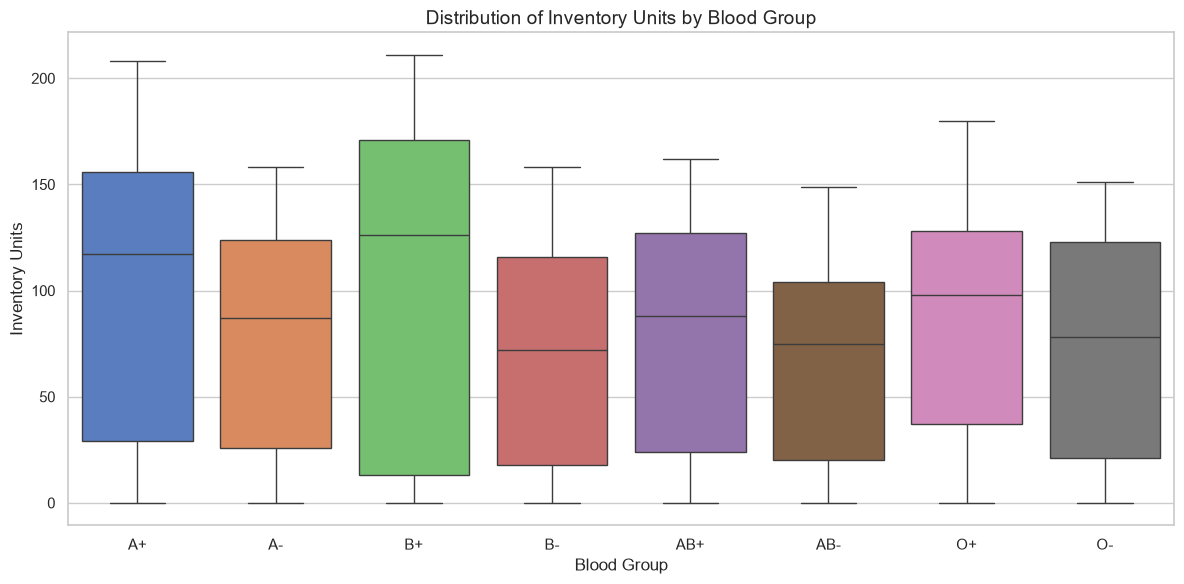

In [5]:
# 1. Distribution of inventory units by Blood Group
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="blood_group", y="inventory_units", palette="muted")
plt.title("Distribution of Inventory Units by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Inventory Units")
plt.tight_layout()
plt.show()

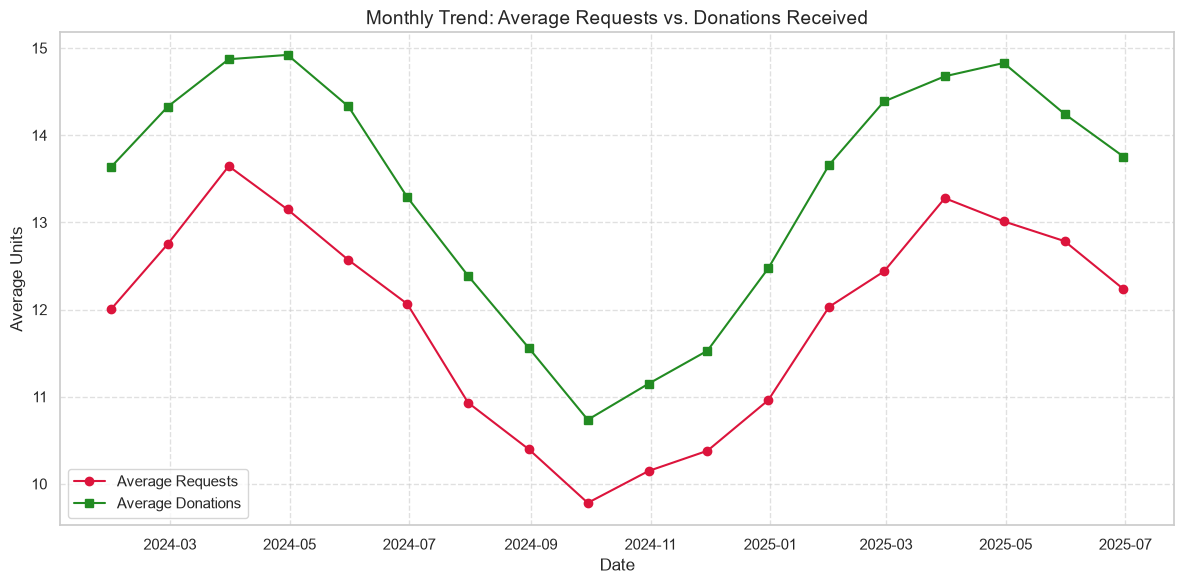

In [6]:
# 2. Monthly Trend of Requests vs Donations (overall)
df_monthly = df.resample('ME', on='record_date')[['requests_received', 'donations_received']].mean()

plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly['requests_received'], marker='o', label='Average Requests', color='crimson')
plt.plot(df_monthly.index, df_monthly['donations_received'], marker='s', label='Average Donations', color='forestgreen')
plt.title("Monthly Trend: Average Requests vs. Donations Received")
plt.xlabel("Date")
plt.ylabel("Average Units")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\dhair\AppData\Local\Temp\ipykernel_12476\2977666315.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x="emergency_event_flag", y="requests_received", ci=95, palette="Oranges")
C:\Users\dhair\AppData\Local\Temp\ipykernel_12476\2977666315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="emergency_event_flag", y="requests_received", ci=95, palette="Oranges")


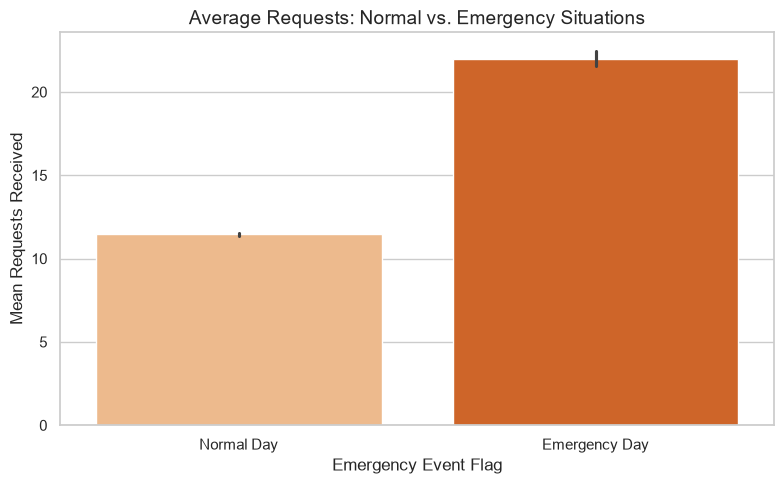

In [7]:
# 3. Emergency vs Non-Emergency requests
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="emergency_event_flag", y="requests_received", ci=95, palette="Oranges")
plt.title("Average Requests: Normal vs. Emergency Situations")
plt.xlabel("Emergency Event Flag")
plt.ylabel("Mean Requests Received")
plt.xticks([0, 1], ['Normal Day', 'Emergency Day'])
plt.tight_layout()
plt.show()